In [3]:
from langgraph.graph import END, START, StateGraph

from graph.route import route_after_hitl
from graph.state import CourtroomState
from nodes.conclusion_node import conclusion_node
from nodes.hitl_node import hitl_node
from nodes.judiciary_node import judiciary_node
from nodes.moderator_node import moderator_node
from nodes.perspective_node import (
    p0_node,
    p1_node,
    p2_node,
    p3_node,
    p4_node,
    p5_node,
    p6_node,
    p7_node,
    p8_node,
    p9_node,
    p10_node,
)
from nodes.query_refine_node import query_refine_node
from dotenv import load_dotenv
load_dotenv(dotenv_path=".env", override=True)

PERSPECTIVE_NODE_NAMES = [
    "p0_node",
    "p1_node",
    "p2_node",
    "p3_node",
    "p4_node",
    "p5_node",
    "p6_node",
    "p7_node",
    "p8_node",
    "p9_node",
    "p10_node",
]


def build_courtroom_graph():
    graph = StateGraph(CourtroomState)

    graph.add_node("moderator_node", moderator_node)
    graph.add_node("query_refine_node", query_refine_node)
    graph.add_node("p0_node", p0_node)
    graph.add_node("p1_node", p1_node)
    graph.add_node("p2_node", p2_node)
    graph.add_node("p3_node", p3_node)
    graph.add_node("p4_node", p4_node)
    graph.add_node("p5_node", p5_node)
    graph.add_node("p6_node", p6_node)
    graph.add_node("p7_node", p7_node)
    graph.add_node("p8_node", p8_node)
    graph.add_node("p9_node", p9_node)
    graph.add_node("p10_node", p10_node)
    graph.add_node("judiciary_node", judiciary_node)
    graph.add_node("hitl_node", hitl_node)
    graph.add_node("conclusion_node", conclusion_node)

    graph.add_edge(START, "query_refine_node")
    graph.add_edge("query_refine_node", "moderator_node")

    for node_name in PERSPECTIVE_NODE_NAMES:
        graph.add_edge("moderator_node", node_name)

    graph.add_edge(PERSPECTIVE_NODE_NAMES, "judiciary_node")
    graph.add_edge("judiciary_node", "hitl_node")

    graph.add_conditional_edges(
        "hitl_node",
        route_after_hitl,
        {
            "moderator_node": "moderator_node",
            "query_refine_node": "query_refine_node",
            "conclusion_node": "conclusion_node",
        },
    )

    graph.add_edge("conclusion_node", END)

    return graph


courtroom_graph = build_courtroom_graph()
courtroom_app = courtroom_graph.compile(interrupt_before=["hitl_node"])


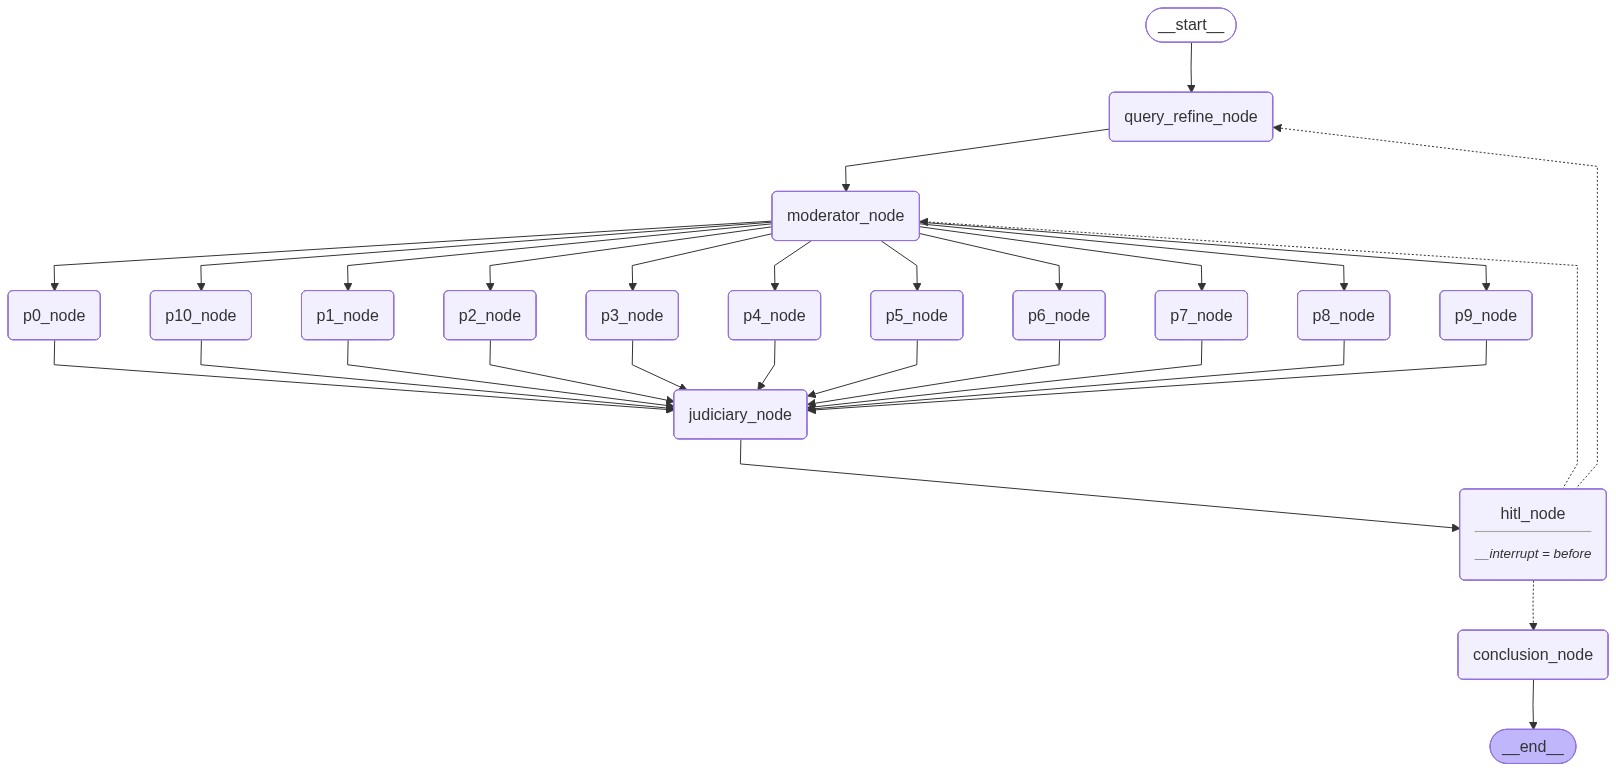

In [4]:
from IPython.display import Image, display

display(
    Image(
        courtroom_app.get_graph(xray=True).draw_mermaid_png()
    )
)